--- PORTFOLIO SUMMARY ---
Total Invested: $29,400.00
Current Value:  $30,567.00
Total P/L:      $1,167.00 (3.97%)

🏆 Best Performer:  XOM (21.12%)
📉 Worst Performer: AAPL (-7.73%)



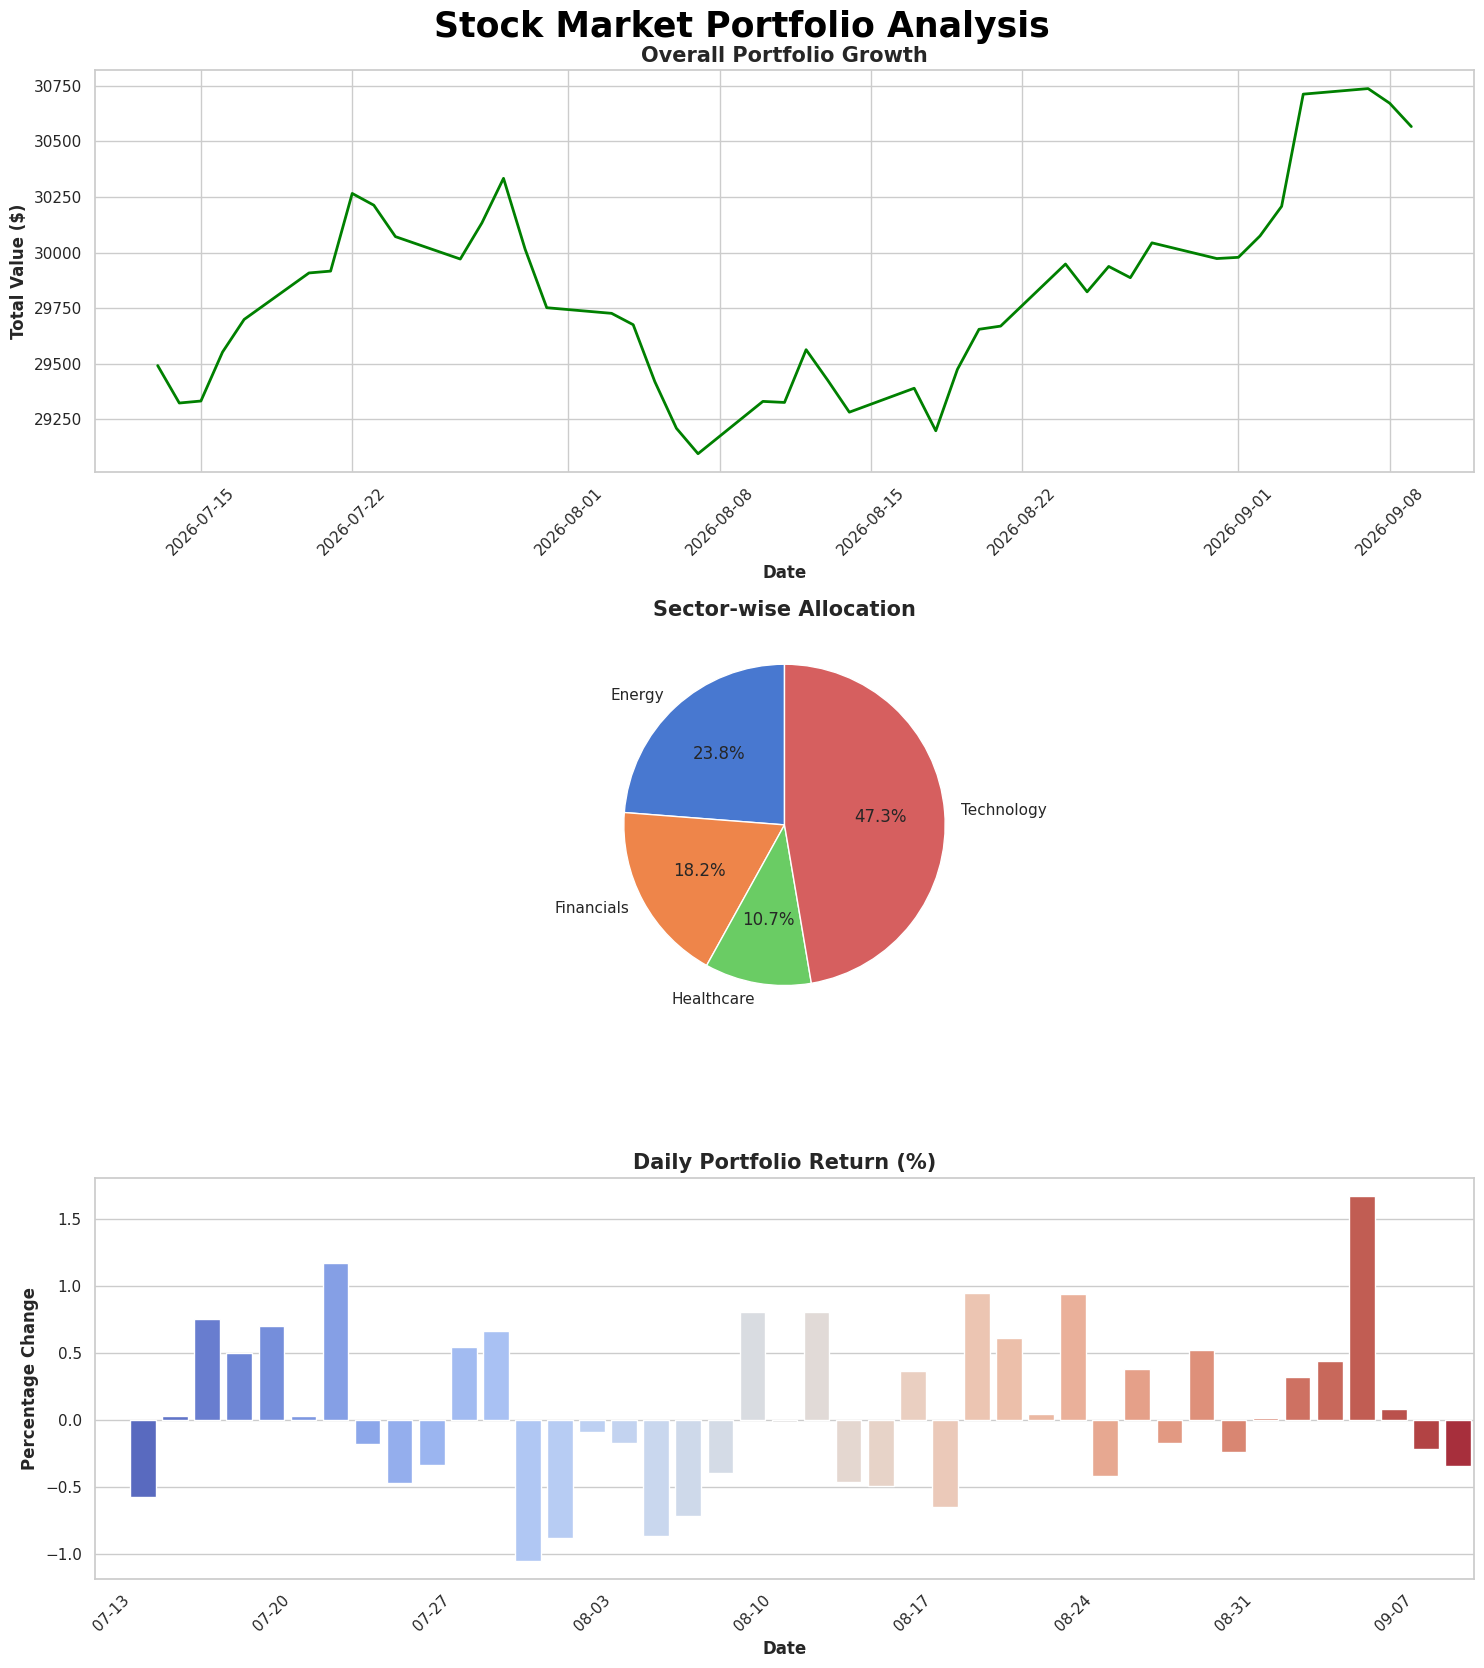

In [36]:
%matplotlib inline 
# above is the magic command which is used to display the image immediately below the cell that created them
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Read stock price data from CSV
df = pd.read_csv('stock_portfolio_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Calculate the daily value of each position
df['Current_Value'] = df['Shares'] * df['Close_Price']
df['Invested_Value'] = df['Shares'] * df['Buy_Price']

# Isolate the latest date to evaluate current Portfolio Status
latest_date = df['Date'].max()
current_portfolio = df[df['Date'] == latest_date].copy()

# 2. Calculate Profit/Loss for each stock
current_portfolio['Profit_Loss'] = current_portfolio['Current_Value'] - current_portfolio['Invested_Value']
current_portfolio['Return_PCT'] = (current_portfolio['Profit_Loss'] / current_portfolio['Invested_Value']) * 100

# 3. Identify Best & Worst Performing Stocks
best_stock = current_portfolio.loc[current_portfolio['Return_PCT'].idxmax()]
worst_stock = current_portfolio.loc[current_portfolio['Return_PCT'].idxmin()]

# 4. Calculate Overall Portfolio Return
total_invested = current_portfolio['Invested_Value'].sum()
total_current = current_portfolio['Current_Value'].sum()
total_profit_loss = total_current - total_invested
overall_return_pct = (total_profit_loss / total_invested) * 100

print("--- PORTFOLIO SUMMARY ---")
print(f"Total Invested: ${total_invested:,.2f}")
print(f"Current Value:  ${total_current:,.2f}")
print(f"Total P/L:      ${total_profit_loss:,.2f} ({overall_return_pct:.2f}%)\n")

print(f"🏆 Best Performer:  {best_stock['Ticker']} ({best_stock['Return_PCT']:.2f}%)")
print(f"📉 Worst Performer: {worst_stock['Ticker']} ({worst_stock['Return_PCT']:.2f}%)\n")

# 5. Generate Visualizations
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3,1, figsize=(15, 17))
fig.suptitle("Stock Market Portfolio Analysis",fontweight="bold",color = "black",fontsize=25)
# Chart A: Portfolio Growth Chart
# Group by date to get the total portfolio value for each day
daily_portfolio = df.groupby('Date')['Current_Value'].sum().reset_index()
sns.lineplot(data=daily_portfolio, x='Date', y='Current_Value', ax=axes[0], color='green', linewidth=2)
axes[0].set_title('Overall Portfolio Growth',fontweight="bold",fontsize=15)
axes[0].set_ylabel('Total Value ($)',fontweight="bold")
axes[0].set_xlabel('Date',fontweight="bold")
axes[0].tick_params(axis='x', rotation=45)

# Chart B: Sector-wise Investment Chart
sector_value = current_portfolio.groupby('Sector')['Current_Value'].sum()
axes[1].pie(sector_value, labels=sector_value.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("muted"))
axes[1].set_title('Sector-wise Allocation',fontweight="bold",fontsize=15)

# Chart C: Daily Return Analysis
# Calculate daily percentage change of the entire portfolio
daily_portfolio['Daily_Return_PCT'] = daily_portfolio['Current_Value'].pct_change() * 100
sns.barplot(data=daily_portfolio, x=daily_portfolio['Date'].dt.strftime('%m-%d'), y='Daily_Return_PCT', ax=axes[2], palette="coolwarm",hue = daily_portfolio['Date'],legend=False)
axes[2].set_title('Daily Portfolio Return (%)',fontweight="bold",fontsize=15)
axes[2].set_xlabel('Date',fontweight="bold")
axes[2].set_ylabel('Percentage Change',fontweight="bold")
# Hide x-labels if they get too crowded, or show every nth label
for ind, label in enumerate(axes[2].get_xticklabels()):
    if ind % 5 == 0:  
        label.set_visible(True)
        label.set_rotation(45)
    else:
        label.set_visible(False)

plt.tight_layout()
plt.show()